INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU, compute capability 8.6
Found 4395 images belonging to 5 classes.
Found 775 images belonging to 5 classes.
Epoch 1/50
138/138 [==============================] - 63s 377ms/step - loss: 2.6949 - accuracy: 0.2109 - auc: 0.5135 - precision: 0.2239 - recall: 0.0230 - f1_metric: 1.9226 - val_loss: 2.0593 - val_accuracy: 0.1935 - val_auc: 0.4989 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_f1_metric: 0.0000e+00 - lr: 0.0010
Epoch 2/50
138/138 [==============================] - 49s 351ms/step - loss: 1.9892 - accuracy: 0.2582 - auc: 0.5762 - precision: 0.3922 - recall: 0.0046 - f1_metric: 2.1719 - val_loss: 1.9801 - val_accuracy: 0.2039 - val_auc: 0.5180 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_f1_metric: 2.1299 - lr: 0.0010
Epoch 3/50

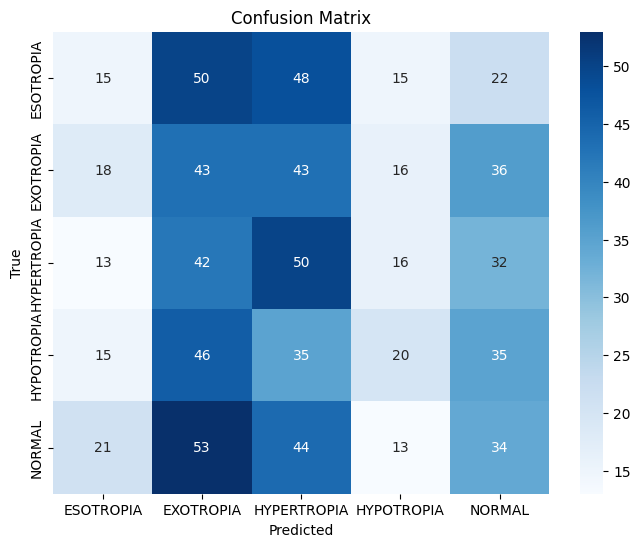

AlexNet model training and optimization complete.


In [9]:
import tensorflow as tf
import tensorflow_addons as tfa
import numpy as np
import cv2
import os
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation, Add, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import Callback, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Define dataset path & parameters
data_dir = "E:/Projects/Strabismus/Denoised"
img_height, img_width = 227, 227
batch_size = 64
num_classes = 5  

# Improved Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))

# Define Improved AlexNet-like model
def AlexNet(input_shape, num_classes):
    base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    return model

# Instantiate model
model = AlexNet((img_height, img_width, 3), num_classes)

# Define learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch > 0:
        return lr * 0.5  # Less aggressive decay
    return lr

callback_lr = LearningRateScheduler(lr_scheduler)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=7, verbose=1)

# Custom F1 Score Metric
def f1_metric(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=1)
    y_true = tf.argmax(y_true, axis=1)
    
    tp = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
    fp = tf.reduce_sum(tf.cast((1 - y_true) * y_pred, tf.float32))
    fn = tf.reduce_sum(tf.cast(y_true * (1 - y_pred), tf.float32))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))

# Compile model
optimizer = tfa.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)

model.compile(optimizer=optimizer, 
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), f1_metric])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model
model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[callback_lr, reduce_lr, early_stopping]
)

# Function to plot confusion matrix
def plot_confusion_matrix(model, generator):
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=generator.class_indices.keys(), yticklabels=generator.class_indices.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot Confusion Matrix
plot_confusion_matrix(model, val_generator)

print("AlexNet model training and optimization complete.")


In [1]:
from sklearn.metrics import classification_report
import pandas as pd

def plot_value_table(model, generator):
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    
    # Compute classification report
    report = classification_report(y_true, y_pred, target_names=generator.class_indices.keys(), output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    
    # Print the table
    print(df_report)
    
    return df_report

# Generate and display value table
df_metrics = plot_value_table(model, val_generator)


NameError: name 'model' is not defined